# One GOES infrared scene

Fetch a single GOES-18 ABI channel-13 CONUS scene, open its NetCDF4 locally,
and inspect brightness temperature with the source quality flags. Available
since v0.8 with `usdata[netcdf]` and the optional examples environment.

Saved outputs record one execution. Restart the kernel and run all cells to
refresh it. This is a whole satellite scene (~3.8 MB), selected by its exact
scan-start timestamp. It is not geographically cropped.

In [1]:
import sys
from datetime import UTC, datetime
from pathlib import Path

import h5netcdf
import h5py
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import usdata
from usdata.pull import pull, verify

manifest = Path("examples/goes-imagery/dataset.yaml")
if not manifest.is_file():
    manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"Python {sys.version.split()[0]}; h5netcdf {h5netcdf.__version__}; h5py {h5py.__version__}")
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; NumPy {np.__version__}")

Executed (UTC): 2026-09-09T00:46:04+00:00
Python 3.14.7; h5netcdf 1.8.1; h5py 3.16.0
usdata 0.7.0; xarray 2026.7.0; NumPy 2.5.2


## Fetch and preserve the input

The manifest explicitly selects satellite 18, channel 13, and ABI-L2-CMIPC.
Both bounds equal the scan start, including its tenth of a second. The first
pull creates a lockfile; later pulls restore its pinned URL and checksum.

In [2]:
result = pull(manifest)
(item,) = result.fetched
print("Source:", item.provenance.source_url)
print("Retrieved (UTC):", item.provenance.retrieved_at.isoformat())
print("Input checksum:", item.provenance.checksum)
print("Bytes:", item.provenance.size)
print("Scan:", item.asset.time.start.isoformat(), "to", item.asset.time.end.isoformat())
assert verify(manifest) == []

Source: s3://noaa-goes18/ABI-L2-CMIPC/2024/127/12/OR_ABI-L2-CMIPC-M6C13_G18_s20241271201181_e20241271203566_c20241271204061.nc
Retrieved (UTC): 2026-09-09T00:46:05.647041+00:00
Input checksum: sha256:3331dc3dcf67f3015e221484750fefebead4c51d728272045c3e31c9123a0c0a
Bytes: 3821830
Scan: 2024-05-06T12:01:18.100000+00:00 to 2024-05-06T12:03:56.600000+00:00


## Open, decode, and keep quality information

`open()` loads the root NetCDF4 Dataset and closes its file handles before
returning. CF scale/offset and fill values are decoded, while coordinate units,
projection metadata, and quality flags remain available. It does not crop,
reproject, or decide which quality flags to accept. Here the analysis explicitly
keeps only `DQF == 0` (the source's `good_pixel_qf`).

In [3]:
scene = item.open()
assert scene["CMI"].attrs["units"] == "K"
assert scene["CMI"].dims == ("y", "x")
assert "good_pixel_qf" in scene["DQF"].attrs["flag_meanings"]
assert scene.attrs["usdata"]["provenance"]["checksum"] == item.provenance.checksum
brightness = scene["CMI"].where(scene["DQF"] == 0)
print("Grid:", dict(scene.sizes))
print("CMI:", scene["CMI"].attrs["long_name"])
print("Units:", scene["CMI"].attrs["units"])
print("Quality flags:", scene["DQF"].attrs["flag_meanings"])
print("Accepted finite pixels:", int(brightness.count()), "of", brightness.size)
print(
    f"Pixel mean: {float(brightness.mean()):.2f} K; range: "
    f"{float(brightness.min()):.2f}-{float(brightness.max()):.2f} K"
)

Grid: {'y': 1500, 'x': 2500, 'number_of_time_bounds': 2, 'number_of_image_bounds': 2, 'band': 1}
CMI: ABI L2+ Cloud and Moisture Imagery brightness temperature
Units: K
Quality flags: good_pixel_qf conditionally_usable_pixel_qf out_of_range_pixel_qf no_value_pixel_qf focal_plane_temperature_threshold_exceeded_qf
Accepted finite pixels: 3750000 of 3750000
Pixel mean: 273.10 K; range: 208.29-296.29 K


## Inspect scan coordinates and pixel temperatures

Channel 13 measures infrared brightness temperature, not necessarily surface
air temperature: clouds and the surface both contribute to the observed scene.
The image below uses the file's geostationary scan angles in radians, not a
latitude/longitude map. The plot uses every fourth grid point for a compact
render; the summary and histogram use every accepted finite pixel. The mean
is a pixel mean, not an area-weighted regional temperature.

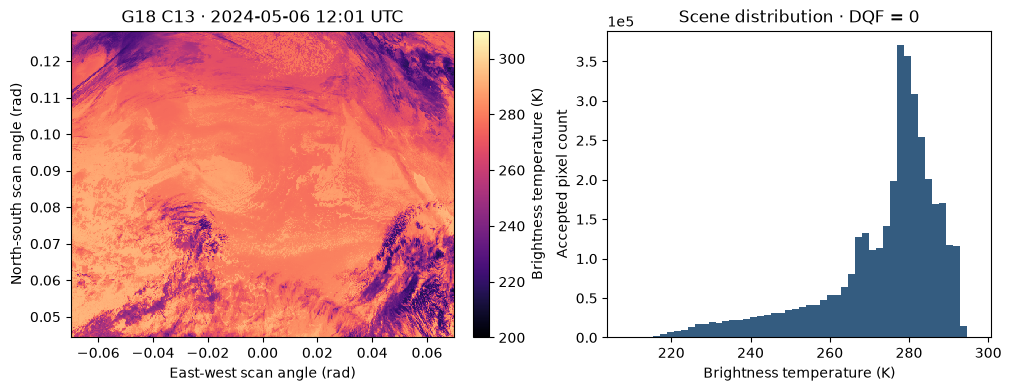

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)
preview = brightness.isel(y=slice(None, None, 4), x=slice(None, None, 4))
mesh = axes[0].pcolormesh(
    preview.x, preview.y, preview, shading="auto", cmap="magma", vmin=200, vmax=310, rasterized=True
)
axes[0].set(
    xlabel="East-west scan angle (rad)",
    ylabel="North-south scan angle (rad)",
    title=(
        f"{scene.attrs['platform_ID']} C{int(scene.band_id.item()):02d} · "
        f"{item.asset.time.start:%Y-%m-%d %H:%M UTC}"
    ),
)
fig.colorbar(mesh, ax=axes[0], label="Brightness temperature (K)")
values = brightness.values
axes[1].hist(values[np.isfinite(values)], bins=50, color="#345c80")
axes[1].set(
    xlabel="Brightness temperature (K)",
    ylabel="Accepted pixel count",
    title="Scene distribution · DQF = 0",
)
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.show()

## Verify the source after analysis

Reading and plotting change neither the cached source nor its provenance.
The returned Dataset is already detached from the file, so it stays usable
without an open HDF5 handle. Keep the manifest, lockfile, and cached bytes for
long-lived reproducibility; upstream revisions can fail a future locked restore.

In [5]:
assert verify(manifest) == []
again = pull(manifest)
assert again.from_lockfile and all(asset.from_cache for asset in again.fetched)
print("Input verified; repeat pull used the lockfile and cache.")
print("Projection:", scene["goes_imager_projection"].attrs["grid_mapping_name"])
print("Original checksum:", scene.attrs["usdata"]["provenance"]["checksum"])

Input verified; repeat pull used the lockfile and cache.
Projection: geostationary
Original checksum: sha256:3331dc3dcf67f3015e221484750fefebead4c51d728272045c3e31c9123a0c0a


Source documentation: [NOAA ABI/CMIP](https://www.ncei.noaa.gov/products/goes-terrestrial-weather-abi-glm),
[NODD public archive](https://registry.opendata.aws/noaa-goes/),
and [usdata GOES access notes](../../docs/providers/noaa.md#goes-abi-conus-imagery).